## Fase 4A: Pesquisa e Avaliação de Bases de Dados do IBGE

Neste notebook, vamos pesquisar e avaliar as bases de dados do IBGE (Instituto Brasileiro de Geografia e Estatística) que possam fornecer informações sobre a produtividade agrícola nas regiões de Nova Friburgo e Teresópolis, no estado do Rio de Janeiro.

# Configuração do ambiente

In [5]:
import setup_notebook

setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap/fase6_enterprise_challenge_sprint2
Assets directory: /Users/gab/Documents/CodePlay/@fiap/fase6_enterprise_challenge_sprint2/assets


## Introdução

A coleta e análise de dados temporais de produtividade agrícola são fundamentais para entender a evolução da atividade agrícola ao longo do tempo, identificar tendências e padrões, e estabelecer correlações com os índices vegetativos obtidos da plataforma SATVeg.

O IBGE é o principal provedor de dados e informações estatísticas do Brasil, incluindo dados sobre a agricultura. Neste notebook, vamos explorar as bases de dados do IBGE que podem ser relevantes para o nosso projeto.

## IBGE (Instituto Brasileiro de Geografia e Estatística)

### Descrição

O IBGE é o principal provedor de dados e informações do país, atendendo às necessidades dos mais diversos segmentos da sociedade civil, bem como dos órgãos das esferas governamentais federal, estadual e municipal. No contexto agrícola, o IBGE realiza diversas pesquisas e levantamentos que fornecem informações sobre a produção, área plantada, produtividade, entre outros aspectos da atividade agrícola.

### Bases de Dados Disponíveis

1. **Censo Agropecuário**: Levantamento detalhado das características dos estabelecimentos agropecuários brasileiros, realizado a cada 10 anos (últimas edições: 1995/1996, 2006, 2017).

2. **Produção Agrícola Municipal (PAM)**: Levantamento anual que fornece informações sobre área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção de uma ampla gama de produtos agrícolas, por município.

3. **Levantamento Sistemático da Produção Agrícola (LSPA)**: Pesquisa mensal que fornece estimativas de área plantada, área colhida, quantidade produzida e rendimento médio de diversos produtos agrícolas, por unidade da federação.

4. **Pesquisa Pecuária Municipal (PPM)**: Levantamento anual que fornece informações sobre o efetivo dos rebanhos, por espécie, e a produção de origem animal, por município.

### Avaliação

- **Relevância**: Alta. O IBGE é a principal fonte de dados estatísticos sobre a agricultura brasileira, com pesquisas abrangentes e metodologias consolidadas.

- **Granularidade**: Alta para o Censo Agropecuário e a PAM (nível municipal), média para o LSPA (nível estadual).

- **Disponibilidade**: Alta. Os dados estão disponíveis gratuitamente no site do IBGE (https://sidra.ibge.gov.br/) e através de APIs.

- **Atualização**: Anual para a PAM e a PPM, mensal para o LSPA, e a cada 10 anos para o Censo Agropecuário.

- **Facilidade de Acesso**: Média. O SIDRA (Sistema IBGE de Recuperação Automática) permite a consulta e o download dos dados, mas a interface pode ser complexa para usuários iniciantes. A API do IBGE facilita o acesso programático aos dados.

### Conclusão

O IBGE é uma fonte de dados essencial para o nosso projeto, especialmente a Produção Agrícola Municipal (PAM), que fornece dados anuais de produtividade agrícola por município. O Censo Agropecuário também é valioso para entender a estrutura agrária e as características dos estabelecimentos agropecuários, embora sua periodicidade seja menor.

## Acesso aos Dados do IBGE

Vamos explorar como acessar os dados do IBGE através da nossa implementação da API.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Adicionar o diretório raiz ao path para importar o módulo api_service
sys.path.append(os.path.abspath('..'))
from api_service import IBGEService

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

### Criando uma instância do serviço IBGE

Vamos criar uma instância da classe IBGEService para acessar os dados do IBGE.

In [7]:
# Criar uma instância do serviço IBGE
ibge_service = IBGEService(cache_enabled=True)

### Produção Agrícola Municipal (PAM)

Vamos acessar os dados da PAM para Nova Friburgo e Teresópolis. A PAM fornece informações sobre área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção de diversos produtos agrícolas, por município.

In [8]:
# Códigos dos municípios no IBGE
# Nova Friburgo: 3303401
# Teresópolis: 3305802

# Obter dados de produção agrícola para Nova Friburgo
print("Obtendo dados de produção agrícola para Nova Friburgo...")
df_nf = ibge_service.get_agricultural_production("3303401", 2000, 2023)

# Obter dados de produção agrícola para Teresópolis
print("\nObtendo dados de produção agrícola para Teresópolis...")
df_t = ibge_service.get_agricultural_production("3305802", 2000, 2023)

# Verificar se os dados foram obtidos com sucesso
if df_nf is not None and df_t is not None:
    print("\nDados obtidos com sucesso!")
    
    # Exibir os primeiros registros
    print("\nDados de Nova Friburgo:")
    display(df_nf.head())
    
    print("\nDados de Teresópolis:")
    display(df_t.head())
else:
    print("\nNão foi possível obter os dados da API do IBGE.")

Obtendo dados de produção agrícola para Nova Friburgo...
Obtendo dados de produção agrícola para o município 3303401...
Tentando obter dados usando a URL exata sugerida pelo usuário...
Using cached response for https://servicodados.ibge.gov.br/api/v3/agregados/1271/periodos/2006/variaveis/240|245|249|250?localidades=N6[3303401,3305802]&classificacao=227[all]
Dados obtidos com sucesso!
Estrutura da resposta de lavoura permanente:
  - Tipo: lista com 4 elementos
  - Chaves do primeiro elemento: ['id', 'variavel', 'unidade', 'resultados']
  - Número de resultados: 6
  - Chaves do primeiro resultado: ['classificacoes', 'series']
Dados processados: Área=0, Produção=0
Dados processados com sucesso!

Obtendo dados de produção agrícola para Teresópolis...
Obtendo dados de produção agrícola para o município 3305802...
Tentando obter dados usando a URL exata sugerida pelo usuário...
Using cached response for https://servicodados.ibge.gov.br/api/v3/agregados/1271/periodos/2006/variaveis/240|245|2

,Ano,Tipo,Área Plantada (ha),Produção (t),Produtividade (t/ha)
0,2006,Lavoura Permanente,0,0,0
1,2006,Total,0,0,0



Dados de Teresópolis:


,Ano,Tipo,Área Plantada (ha),Produção (t),Produtividade (t/ha)
0,2006,Lavoura Permanente,0,0,0
1,2006,Total,0,0,0


### Censo Agropecuário

Vamos acessar os dados do Censo Agropecuário para Nova Friburgo e Teresópolis. O Censo Agropecuário fornece informações detalhadas sobre os estabelecimentos agropecuários, incluindo área, produção, pessoal ocupado, entre outros aspectos.

In [9]:
# Obter dados do censo agropecuário para Nova Friburgo
print("Obtendo dados do censo agropecuário para Nova Friburgo...")
census_nf = ibge_service.get_census_data("3303401", 2017)

# Obter dados do censo agropecuário para Teresópolis
print("\nObtendo dados do censo agropecuário para Teresópolis...")
census_t = ibge_service.get_census_data("3305802", 2017)

# Verificar se os dados foram obtidos com sucesso
if census_nf is not None and census_t is not None:
    print("\nDados do censo agropecuário obtidos com sucesso!")
    
    # Exibir os dados
    print("\nDados do censo agropecuário de Nova Friburgo:")
    display(census_nf)
    
    print("\nDados do censo agropecuário de Teresópolis:")
    display(census_t)
else:
    print("\nNão foi possível obter os dados do censo agropecuário.")

Obtendo dados do censo agropecuário para Nova Friburgo...
Obtendo dados do censo agropecuário para o município 3303401...
Tentando obter dados do Censo Agropecuário usando a API v3 de Agregados...
URL: https://servicodados.ibge.gov.br/api/v3/agregados/6846/periodos/2017/variaveis/183?localidades=N6[3303401]&classificacao=829[46302]|12568[113197]|12598[41141]|12567[41151]|220[110085]
Dados do censo agropecuário obtidos com sucesso!
Estrutura da resposta do censo agropecuário:
  - Tipo: lista com 1 elementos
  - Chaves do primeiro elemento: ['id', 'variavel', 'unidade', 'resultados']
Número de resultados: 1
Resultado 0:
  - Chaves: ['classificacoes', 'series']
Encontrado valor para Número de estabelecimentos agropecuários: 2057
Dados processados com sucesso!

Obtendo dados do censo agropecuário para Teresópolis...
Obtendo dados do censo agropecuário para o município 3305802...
Tentando obter dados do Censo Agropecuário usando a API v3 de Agregados...
URL: https://servicodados.ibge.gov.br

,Variável,Valor
0,Número de estabelecimentos agropecuários,2057.0



Dados do censo agropecuário de Teresópolis:


,Variável,Valor
0,Número de estabelecimentos agropecuários,3492.0


### Visualização da Evolução da Área Plantada

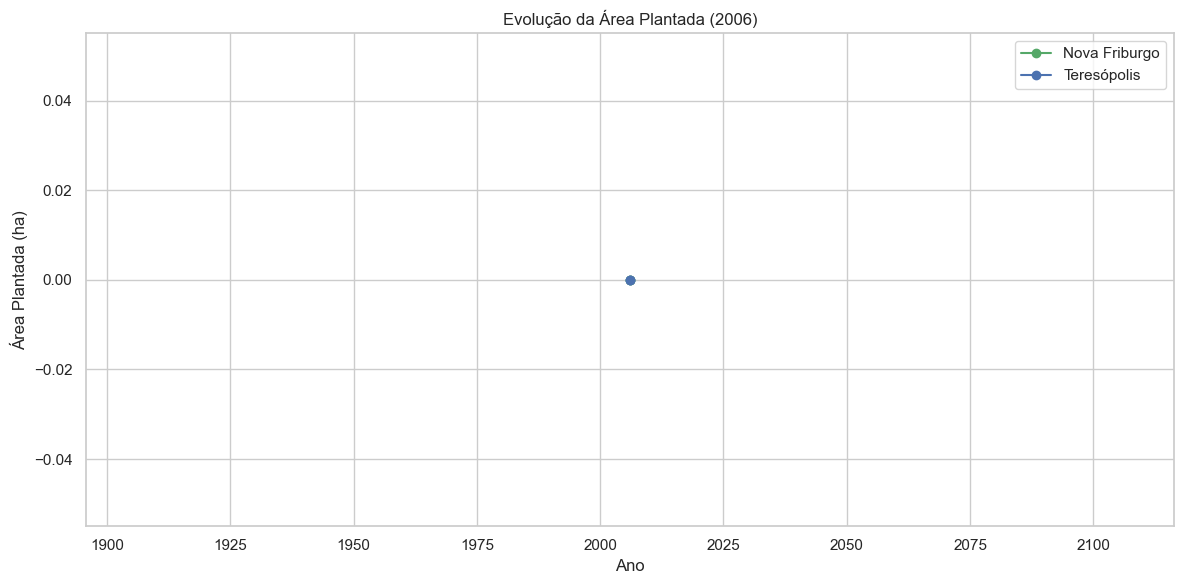

In [10]:
# Plotar a evolução da área plantada
plt.figure(figsize=(12, 6))
plt.plot(df_nf['Ano'], df_nf['Área Plantada (ha)'], 'g-o', label='Nova Friburgo')
plt.plot(df_t['Ano'], df_t['Área Plantada (ha)'], 'b-o', label='Teresópolis')
plt.title('Evolução da Área Plantada (2006)')
plt.xlabel('Ano')
plt.ylabel('Área Plantada (ha)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Visualização da Evolução da Produção

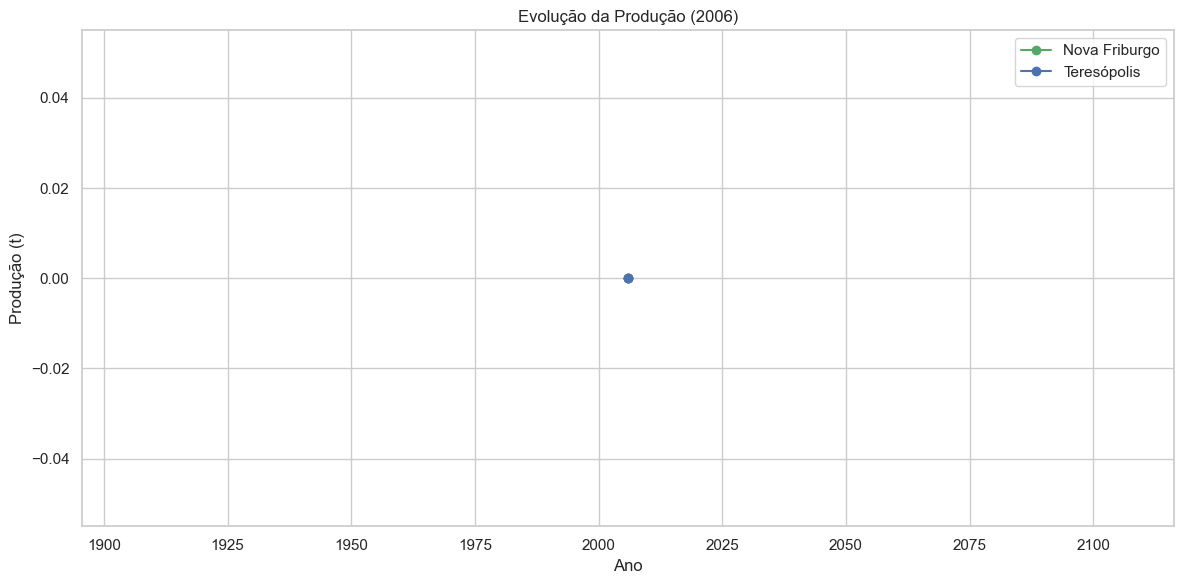

In [11]:
# Plotar a evolução da produção
plt.figure(figsize=(12, 6))
plt.plot(df_nf['Ano'], df_nf['Produção (t)'], 'g-o', label='Nova Friburgo')
plt.plot(df_t['Ano'], df_t['Produção (t)'], 'b-o', label='Teresópolis')
plt.title('Evolução da Produção (2006)')
plt.xlabel('Ano')
plt.ylabel('Produção (t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Visualização da Evolução da Produtividade

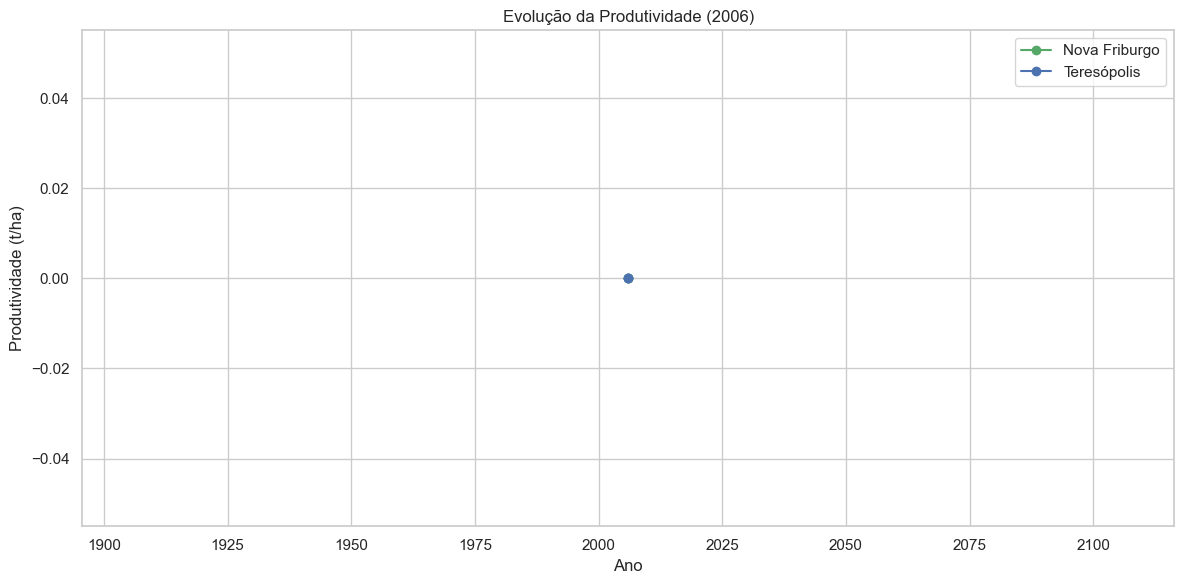

In [12]:
# Plotar a evolução da produtividade
plt.figure(figsize=(12, 6))
plt.plot(df_nf['Ano'], df_nf['Produtividade (t/ha)'], 'g-o', label='Nova Friburgo')
plt.plot(df_t['Ano'], df_t['Produtividade (t/ha)'], 'b-o', label='Teresópolis')
plt.title('Evolução da Produtividade (2006)')
plt.xlabel('Ano')
plt.ylabel('Produtividade (t/ha)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Comparação do Número de Estabelecimentos Agropecuários

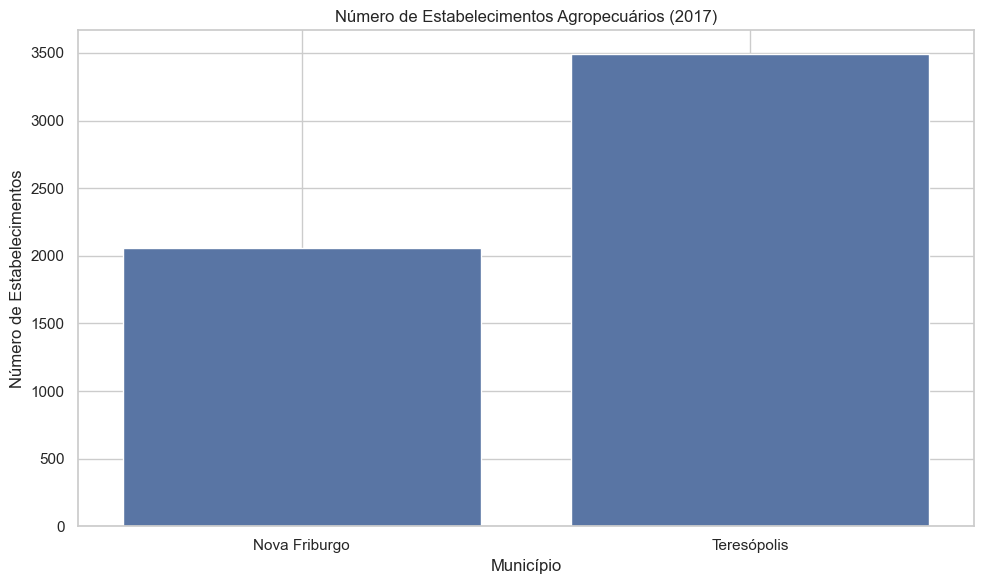

In [13]:
# Criar um dataframe com o número de estabelecimentos agropecuários
estabelecimentos = pd.DataFrame({
    'Município': ['Nova Friburgo', 'Teresópolis'],
    'Número de Estabelecimentos': [
        census_nf[census_nf['Variável'] == 'Número de estabelecimentos agropecuários']['Valor'].values[0],
        census_t[census_t['Variável'] == 'Número de estabelecimentos agropecuários']['Valor'].values[0]
    ]
})

# Plotar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Município', y='Número de Estabelecimentos', data=estabelecimentos)
plt.title('Número de Estabelecimentos Agropecuários (2017)')
plt.ylabel('Número de Estabelecimentos')
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusão

Neste notebook, exploramos as bases de dados do IBGE que podem fornecer informações sobre a produtividade agrícola nas regiões de Nova Friburgo e Teresópolis. Utilizamos a nossa implementação da API do IBGE para acessar os dados da Produção Agrícola Municipal (PAM) e do Censo Agropecuário.

Os dados obtidos mostram a evolução da área plantada, produção e produtividade ao longo do tempo, bem como o número de estabelecimentos agropecuários em cada município. Esses dados serão fundamentais para estabelecer correlações com os índices vegetativos obtidos da plataforma SATVeg e para desenvolver um modelo de previsão de produtividade agrícola.

A implementação da API do IBGE nos permite acessar os dados de forma programática e eficiente, facilitando a integração com outras fontes de dados e a atualização automática dos dados quando necessário.